In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output


In [2]:
number_of_qubits = 8

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

#Functions

In [4]:
def Good_vectors(nq):
    sum_spin = math.ceil((nq - 1) / 2 )
    good_vectors = basis.sum(dim = 1)
    good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
    sub_batch = torch.zeros(good_vectors.shape[0], nq)
    i = torch.arange(0, good_vectors.shape[0], 1)
    #print(i.shape, good_vectors.shape)
    sub_batch[i, :] = basis[good_vectors, :]
    good_batch = sub_batch
    a = 2**torch.arange(nq -1, -1,-1)
    num_batch = good_batch*a 
    num_batch = num_batch.sum(dim = 1)

    return good_vectors, good_batch, num_batch

In [5]:
def int10tobase_torch(num,base=2):
  c = num
  max_digit = nq-1
  res = torch.zeros((max_digit+1,num.shape[0]),dtype = torch.long)
  i = max_digit
  while(torch.sum(c)!=0):
    res[i,:] = torch.remainder(c,base)
    c = (c/base).type(torch.long)
    i-=1
  return res.t()

In [6]:
def permutations():
  main = torch.ones(nq)
  i = torch.arange(1,nq,2)
  main[i] = 0
  #print(main)
  a = 2**torch.arange(nq -1, -1,-1)
  num_main = (main*a).sum()
  #print(num_main)
  #new = torch.zeros(nq,nq-1)
  pm = torch.clone(main.reshape(1,nq).expand(nq-1,nq))
  for i in range(nq - 1):
    pm[i,i] = 1 - main[i]
    pm[i,i+1] = 1 - main[i+1]
  i = torch.arange(nq-1)
  res = torch.zeros(nq - 1, nq)
  ress = torch.zeros(nq - 1)
  res[i] = pm[i]*a 
  ress[i] = res[i].sum(dim = 1)
  batch = torch.cat((main.view(1,nq),pm), 0)
  ress = torch.cat((num_main.view(1),ress),0)
  t = ress.sort()
  i = torch.arange(nq)
  batch2 = torch.zeros(batch.shape[0], batch.shape[1])
  batch2[i,:] =  batch[t.indices[i],:]

  main[0] = 1
  main[nq-1] = 0
  batch2 = torch.cat((batch2, main.view(1,main.shape[0])), 0)
  last = (main*a).sum() 
  print(last)
  t = torch.cat((t.values.long().view(-1), last.view(-1)), 0)
  print(t) 
  return batch2, t

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [8]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
def sparce_m_OBC(batch, number_of_qubits, m):
    batch_new = torch.clone(batch).to(device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1

    row = torch.arange(0,batch.shape[0]).to(device)
    col = torch.arange(0,batch.shape[0]).to(device)
    data = torch.zeros(batch.shape[0]).to(device)
    
    t = torch.arange(0,number_of_qubits).to(device)
    batch_new[:,t] *= (-1)**(t)
    ##
    batch_new[:,t]  -= 1
    ##
    data[row] = -batch_new[row].sum(1)
    data *= m/2
    return data


def sparce_iter(batch, number_of_qubits):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch).to(device)
    batch_new[batch_new == 0] = -1
    row = torch.arange(0,batch.shape[0]).to(device)
    col = torch.arange(0,batch.shape[0]).to(device)
    
    
    data = torch.zeros(batch.shape[0]).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       
    
    data[row] = (batch_new[row]*coef).sum(dim = 1)
    
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch.shape[0]).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        data[row] += batch_new[row,i]*s[row]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I 
    #print(C)
    data += I
    return  data/4

In [9]:
def sparce_diag(nq, m, x, device, level):
    row = []
    col = []
    sum_spin = math.ceil((nq - 1) / 2 - level)
    for i in range(nq - 1):
        ind = torch.tensor([i,i+1])
        good_batch_2 = torch.clone(good_batch).to(device)
        good_batch_2[:,ind] = 1 - good_batch_2[:,ind]
        r = (good_batch_2.sum(1) == sum_spin).nonzero().reshape(-1).to(device)
        a = 2**torch.arange(nq -1, -1,-1).to(device)
        out = good_batch_2[r]*a 
        out = out.sum(dim = 1).to(device)
        #print(out.device)
        res = (out.unsqueeze(1) == num_batch).nonzero()
        #print(num_batch)
        col.append(r.cpu().numpy())
        row.append(res[:,1].cpu().numpy())
    # ind = torch.tensor([0,nq - 1])
    # good_batch_2 = torch.clone(good_batch).to(device)
    # good_batch_2[:,ind] = 1 - good_batch_2[:,ind]
    # r = (good_batch_2.sum(1) == sum_spin).nonzero().reshape(-1).to(device)
    # a = 2**torch.arange(nq -1, -1,-1).to(device)
    # out = good_batch_2[r]*a 
    # out = out.sum(dim = 1).to(device)
    # res = (out.unsqueeze(1) == num_batch).nonzero()
    #     #print(num_batch)
    # col.append(r.cpu().numpy())
    # row.append(res[:,1].cpu().numpy())
    # #print(row)
    row_xy = torch.tensor(row).reshape(-1).to(device)
    col_xy = torch.tensor(col).reshape(-1).to(device)
    data_xy = torch.ones(col_xy.shape[0]).to(device)

    row = torch.arange(0,good_batch.shape[0]).to(device)
    col = torch.arange(0,good_batch.shape[0]).to(device)
    good_batch.to(device)
    data = sparce_m_OBC(good_batch,nq, m) + sparce_iter(good_batch,nq)
    Row = torch.cat((row, row_xy), 0)
    Col = torch.cat((col, col_xy), 0)
    Data = torch.cat((data, data_xy*x), 0)
    
    eigenvalues, eigenvectors = eigsh(csr_matrix((Data.cpu(), (Row.cpu(), Col.cpu())), shape=(good_batch.shape[0], good_batch.shape[0])).astype(float), k=2, which = 'SA')
    return eigenvalues, eigenvectors

In [10]:
def sparce_diag_matrix(nq, m, x, device, level):
    row = []
    col = []
    sum_spin = math.ceil((nq - 1) / 2 - level)
    for i in range(nq - 1):
        ind = torch.tensor([i,i+1])
        good_batch_2 = torch.clone(good_batch).to(device)
        good_batch_2[:,ind] = 1 - good_batch_2[:,ind]
        r = (good_batch_2.sum(1) == sum_spin).nonzero().reshape(-1).to(device)
        a = 2**torch.arange(nq -1, -1,-1).to(device)
        out = good_batch_2[r]*a 
        out = out.sum(dim = 1).to(device)
        res = (out.unsqueeze(1) == num_batch).nonzero()
        #print(num_batch)
        col.append(r.cpu().numpy())
        row.append(res[:,1].cpu().numpy())
    # ind = torch.tensor([0,nq - 1])
    # good_batch_2 = torch.clone(good_batch).to(device)
    # good_batch_2[:,ind] = 1 - good_batch_2[:,ind]
    # r = (good_batch_2.sum(1) == sum_spin).nonzero().reshape(-1).to(device)
    # a = 2**torch.arange(nq -1, -1,-1).to(device)
    # out = good_batch_2[r]*a 
    # out = out.sum(dim = 1).to(device)
    # res = (out.unsqueeze(1) == num_batch).nonzero()
    #     #print(num_batch)
    # col.append(r.cpu().numpy())
    # row.append(res[:,1].cpu().numpy())
    # #print(row)
    row_xy = torch.tensor(row).reshape(-1).to(device)
    col_xy = torch.tensor(col).reshape(-1).to(device)
    data_xy = torch.ones(col_xy.shape[0]).to(device)

    row = torch.arange(0,good_batch.shape[0]).to(device)
    col = torch.arange(0,good_batch.shape[0]).to(device)
    good_batch.to(device)
    data = sparce_m_OBC(good_batch,nq, m) + sparce_iter(good_batch,nq)
    Row = torch.cat((row, row_xy), 0)
    Col = torch.cat((col, col_xy), 0)
    Data = torch.cat((data, data_xy*x), 0)
    
    eigenvalues, eigenvectors = eigsh(csr_matrix((Data.cpu(), (Row.cpu(), Col.cpu())), shape=(good_batch.shape[0], good_batch.shape[0])).astype(float), k=2, which = 'SA')
    return eigenvalues, eigenvectors, Data, Row, Col

In [11]:
x_param = 1
m = 0.1

In [12]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [13]:
def Get_H_B(m,x, number_of_qubits):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)
    res_XY *= x
    #print(res_XY)

    # mass term
    for i in range(0, number_of_qubits ):
        mass = one
        one_one = one
        for j in range(0, number_of_qubits-2 - i):
            mass = TensorProduct(one, mass)
            one_one = TensorProduct(one, one_one)
        if i == (number_of_qubits - 1):
            mass = pauli_3
            one_one = one
        else:
            mass = TensorProduct(pauli_3, mass)
            one_one = TensorProduct(one, one_one)
        for j in range(0, i):
            mass = TensorProduct(one, mass)
            one_one = TensorProduct(one, one_one)
    
        res_mass += (-1)**i * (torch.from_numpy(mass)) + one_one
    
       
    #print(res_mass)

    # iteraction term
    for i in range(0,number_of_qubits -1):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(0, i + 1):
        
            ite = one
        
            for k in range(0, number_of_qubits - j - 2):
                ite = TensorProduct(one, ite)
            if j == (number_of_qubits - 1):
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(0, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(0,number_of_qubits-1):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 

In [14]:
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)

def make_batch(batch_size):
    return torch.randint(0,2,(batch_size,number_of_qubits)).type(torch.FloatTensor)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])


In [ ]:
one = np.array([[1., 0.],[0.,1.]])
pauli_1 = np.array([[0.,1.],[1.,0.]])
pauli_2 = np.array([[0., 0-1j],[0 +1j, 0.]])
pauli_3 = np.array([[1.,0.],[0., -1.]])
plus = (1/2 * (pauli_1 + 1.j * pauli_2)).real
minus = (1/2 * (pauli_1 - 1.j * pauli_2)).real

In [15]:
#Hamiltonian
#number_of_qubits = 2
#m = 0.1

def Get_H(m, number_of_qubits):
    res_XY = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_mass = torch.zeros(2**number_of_qubits, 2**number_of_qubits)
    res_iter = torch.zeros(2**number_of_qubits, 2**number_of_qubits)


    # XY term
    first = one
    for i in range(1,number_of_qubits):
        #print(i)
        first = one
        second = one
        for j in range(1, number_of_qubits -i-1):
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        if i != number_of_qubits - 1 :
            first = TensorProduct(minus, first)
            first = TensorProduct(plus, first)
            second = TensorProduct(plus, second)
            second = TensorProduct(minus, second)
        else:
            first = TensorProduct(plus, minus)
            second = TensorProduct(minus, plus)
        for j in range(1,i):
            #print("uu")
            first = TensorProduct(one, first)
            second = TensorProduct(one, second)
        #print(c.size())
        res_XY += torch.from_numpy(first + second)

    #print(res_XY)

    # mass term
    for i in range(1, number_of_qubits + 1):
        mass = one
        for j in range(1, number_of_qubits - i):
            mass = TensorProduct(one, mass)
        if i == number_of_qubits:
            mass = pauli_3
        else:
            mass = TensorProduct(pauli_3, mass)
        for j in range(1, i):
            mass = TensorProduct(one, mass)
    
        res_mass += (-1)**i * (torch.from_numpy(mass))
    
       
    #print(res_mass)

    # iteraction term
    for i in range(1,number_of_qubits ):
        res_ite = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        res_ones = torch.zeros(2**number_of_qubits , 2**number_of_qubits)
        for j in range(1, i + 1):
        
            ite = one
        
            for k in range(1, number_of_qubits - j):
                ite = TensorProduct(one, ite)
            if j == number_of_qubits:
                ite = pauli_3
            else:
                ite = TensorProduct(pauli_3, ite)
            for k in range(1, j):
                ite = TensorProduct(one, ite)
            res_ite += (torch.from_numpy(ite)) 
            ones = one
        
            for k in range(1,number_of_qubits):
                ones = TensorProduct(one, ones)
            res_ones += (-1)**j*(torch.from_numpy(ones))
        res_iter += torch.matmul(res_ones + res_ite, res_ones + res_ite)   
    
    
    return 1/4*res_iter + res_XY + m/2*res_mass 
#H = Get_H(0.2,2)
#I = torch.zeros(2**number_of_qubits,2**number_of_qubits)
#for i in range(2**number_of_qubits):
#    I[i][i] = 1.579100
#H = H +I
#print(H)

In [16]:
def matrix_element_iter_new(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    C = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1).to(device)
    
    coef_first = number_of_qubits - number_of_qubits % 2
    coef = torch.zeros(number_of_qubits ).to(device)
    
    for i in range(number_of_qubits -1):
        coef[i] = -coef_first
        if i%2 == 0 : 
            coef_first = coef_first-2       

    C[j,j] = -(batch_new[j]*coef).sum(dim = 1)
    coef_2 = (torch.arange(number_of_qubits -2, 0, -1)*2).to(device)
    
    for i in range(0,number_of_qubits-1):
        s = torch.zeros(batch_size).to(device)
        for m in range(i+1, number_of_qubits-1):
            #print(m, coef_2[m-1])
            s += coef_2[m - 1]*batch_new[:,m]
            #print(s)
        #print(s)    
        C[j,j] += batch_new[j,i]*s[j]
       
    One = torch.eye(batch_size, batch_size).to(device)
    I = torch.tensor([range(0,number_of_qubits)]).sum()
    I += math.floor(number_of_qubits/2)
    One *= I    
    return (C + One)/4
                
            
def matrix_element_xy(batch):
    batch_size = batch.shape[0]
    batch_new = torch.clone(batch)
    batch_new[batch_new == 0] = -1
    
    place = torch.zeros(number_of_qubits -1,2)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][0]= i
        place[i][1] = i+1
    outt = torch.arange(batch_size)
    for i in outt:
        for j in outt:
            true = (torch.nonzero(batch_new[i] != batch_new[j])).reshape(-1)
            if (true.shape[0] == 2) and ((true == place).prod(dim = 1).sum()):
                C[i,j] = 1 -batch_new[i,true[0]]*batch_new[i,true[1]]
    return C/2

def matrix_element_m(batch):

    batch_new = torch.clone(batch)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    
    t = torch.arange(0,number_of_qubits,1).to(device)
    
    batch_new[:,t] *= (-1)**(t+1)
    
    M = torch.zeros(batch_size, batch_size).to(device)
    j = torch.arange(0,batch_size,1)
    M[j,j] = -batch_new.sum(dim = 1)
        #N+= M
    return m/2*M

def matrix_element_xy_new_7(batch):
    batch_new = torch.clone(batch)
    #print(batch_new.device)
    batch_size = batch.shape[0]
    batch_new[batch_new == 0] = -1
    res = batch_new.unsqueeze(1) != batch_new
    
    place = torch.zeros(number_of_qubits -1,number_of_qubits).to(device)
    C = torch.zeros(batch_size, batch_size).to(device)
    
    for i in range(number_of_qubits-1):
        place[i][i]= 1
        place[i][i+1] = 1
        true = torch.nonzero((res == place[i]).prod(dim = 2)==1)
        ress = batch_new[true[:,0],i]*batch_new[true[:,0],i+1]
        C[true[:,0], true[:,1]] = 1 - ress
    return C/2

def matrix(batch):               
    return  matrix_element_iter_new(batch) + matrix_element_xy_new_7(batch) + matrix_element_m(batch)

In [17]:
class MaskedLinear(nn.Linear):
    def __init__(self, in_channels, out_channels, bias, exclusive):
        super(MaskedLinear, self).__init__(in_channels, out_channels,
                                           bias)
        self.in_channels = in_channels
        self.out_channels = out_channels
        #self.n = n
        self.exclusive = exclusive

        self.register_buffer('mask', torch.ones([self.in_channels]*2))
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        #self.mask = torch.cat([self.mask] * in_channels, dim=1)
        #self.mask = torch.cat([self.mask] * out_channels, dim=0)
        self.weight.data *= self.mask

        # Correction to Xavier initialization
        #print(self.weight.data)
        self.weight.data *= torch.sqrt(self.mask.numel() / self.mask.sum())
        #print(self.weight.data)
        
    def forward(self, x):
        return nn.functional.linear(x, self.mask * self.weight, self.bias)

    def extra_repr(self):
        return (super(MaskedLinear, self).extra_repr() +
                ', exclusive={exclusive}'.format(**self.__dict__))

In [18]:
class MaskedLinear2(nn.Linear):
    def __init__(self, in_channels, out_channels, n, bias, exclusive):
        super(MaskedLinear2, self).__init__(in_channels * n, out_channels * n,
                                           bias)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.n = n
        self.exclusive = exclusive

        self.register_buffer('mask', torch.ones([self.n] * 2))
        if self.exclusive:
            self.mask = 1 - torch.triu(self.mask)
        else:
            self.mask = torch.tril(self.mask)
        self.mask = torch.cat([self.mask] * in_channels, dim=1)
        self.mask = torch.cat([self.mask] * out_channels, dim=0)
        
        #print(self.weight.data)
        #self.weight.data.normal_(0.0, 0.0002)
        #print(self.weight.data)
        
        self.weight.data *= self.mask

        # Correction to Xavier initialization
        self.weight.data *= torch.sqrt(self.mask.numel() / self.mask.sum())

    def forward(self, x):
        return nn.functional.linear(x, self.mask * self.weight, self.bias)

    def extra_repr(self):
        return (super(MaskedLinear, self).extra_repr() +
                ', exclusive={exclusive}'.format(**self.__dict__))


In [21]:
m = 0.1
H = Get_H_B(m,1, number_of_qubits).to(device)
#print(H)
torch.set_printoptions(precision=5)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[0]
print(c,m)
#print(net.loss(net(basis)/net(basis).norm()), 'loss через H')
#print(torch.sort(eig_values))


tensor(-3.05945, device='cuda:0') tensor(-3.05945, device='cuda:0')


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:5: UserWarning: torch.eig is deprecated in favor of torch.linalg.eig and will be removed in a future PyTorch release.
torch.linalg.eig returns complex tensors of dtype cfloat or cdouble rather than real tensors mimicking complex tensors.
L, _ = torch.eig(A)
should be replaced with
L_complex = torch.linalg.eigvals(A)
and
L, V = torch.eig(A, eigenvectors=True)
should be replaced with
L_complex, V_complex = torch.linalg.eig(A) (Triggered internally at  /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2897.)
  """


In [47]:
class Net_auto(nn.Module):
    
    lr = 0.005 
    N_epochs = 1000
    
    def __init__(self):
        super(Net_auto,self).__init__()
        #self.Linear0 = MaskedLinear(number_of_qubits, number_of_qubits, bias = True, exclusive=True)
        #self.Linear1 = MaskedLinear(number_of_qubits, number_of_qubits, bias = True, exclusive=False)
        #self.Linear2 = MaskedLinear(number_of_qubits, number_of_qubits, bias = True, exclusive=False)
        #self.Linear3 = MaskedLinear(number_of_qubits, number_of_qubits, bias = True, exclusive=False)
        #self.Linear4 = MaskedLinear(number_of_qubits, number_of_qubits, bias = True, exclusive=False)
        #self.Linear5 = MaskedLinear(number_of_qubits, number_of_qubits, bias = True, exclusive=False)
        self.Linear0 = MaskedLinear2(1, 1, number_of_qubits, bias = True, exclusive=True)
        self.Linear1 = MaskedLinear2(1, 1, number_of_qubits, bias = True, exclusive=False)
        self.Linear2 = MaskedLinear2(1, 1, number_of_qubits, bias = True, exclusive=False)
        self.Linear3 = MaskedLinear2(1, 1, number_of_qubits, bias = True, exclusive=False)
        self.Linear4 = MaskedLinear2(1, 1, number_of_qubits, bias = True, exclusive=False)
        self.Linear5 = MaskedLinear2(1, 1, number_of_qubits, bias = True, exclusive=False)
        #self.Linear0 = nn.Linear(number_of_qubits, number_of_qubits)
        #self.Linear1 = nn.Linear(number_of_qubits, number_of_qubits)
        #self.Linear2 = nn.Linear(number_of_qubits, number_of_qubits)
         
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.bn0 = nn.BatchNorm1d(number_of_qubits)
        self.ln = nn.LogSoftmax()
        self.elu = nn.ELU()
    
    def forward(self,a):
        
        x = self.Linear0(a)
        x = self.tanh(x)
        #x = self.sigmoid(x)
        #x = self.bn0(x)
        
        
        x = self.Linear1(x)
        x = self.tanh(x)
        #x = self.bn0(x)
        
        x = self.Linear2(x)
        x = self.tanh(x)   
        
        x = self.Linear3(x)
        x = self.tanh(x)  
        
        x = self.Linear4(x)
        x = self.tanh(x)  
        
        x = self.Linear5(x)
        x = self.tanh(x)
        
        return x
    def loss3(self,batch):
        # batch2 = make_batch(batch_size).to(device)
        # batch = torch.cat((batch, batch2), 0).to(device)
        out, num = torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        #print(out.size())
        Psi = torch.zeros(out.shape[0], number_of_qubits).to(device)
        # print(Psi.shape)
        # print(psi.shape)
        Psi[out == 1] = psi[out == 1]
        Psi[out == 0] = torch.sqrt(torch.abs(1 + 0.000001 - psi[out == 0]**2))
        psi = Psi
        
        psi = psi.prod(dim =1)
        E = psi.sum()/psi[3] - 2
        return E
    
    def loss(self,batch):
        batch2 = make_batch(batch_size).to(device)
        batch = torch.cat((batch, batch2), 0).to(device)
        out, num = torch.unique(batch, return_counts = True,dim = 0)
        psi = new(out)
        #print(out.size())
        Psi = torch.zeros(out.shape[0], number_of_qubits).to(device)
        Psi[out == 1] = psi[out == 1]
        Psi[out == 0] = torch.sqrt(torch.abs(1 + 0.000001 - psi[out == 0]**2))
        psi = Psi
        
        psi = psi.prod(dim =1)
        psi = psi/psi.norm()
        
        M = matrix(out)
        E = torch.matmul(torch.transpose(psi.view(out.shape[0],1), 0, 1), torch.matmul(M, psi))
        
        return E

    def loss2(self, batch):
        psi = new(batch)
        out = batch
        Psi = torch.zeros(out.shape[0], number_of_qubits).to(device)
        Psi[out == 1] = psi[out == 1]
        Psi[out == 0] = torch.sqrt(torch.abs(1 + 0.000001 - psi[out == 0]**2))
        psi = Psi
        psi = psi.prod(dim =1)
        psi = psi/psi.norm()
        
        
        M = build_H.matrix(out, m, number_of_qubits)
        psi = psi.view(out.shape[0],1)
        M = M * psi
        psi = psi.view(1,out.shape[0])
        M = M / psi
        res = M.sum()
        
        return res/out.shape[0]
    
    def sample(self, batch): 
        for i in range(1):
            for k in range(0,number_of_qubits):
                batch_prob = (new(batch)**2).to(device)
            
                u = torch.rand(batch_size).to(device)
                a = batch_prob[:,k].to(device)
                #print(batch_prob)
                
                batch[u >= a, k] = 0
                batch[u < a, k] = 1
        #print(batch)
        #out, num = torch.unique(batch, return_counts = True,dim = 0)
        #print(out.size(), 'sample')
        return batch
    
    def optimize(self,inp):
        optimizer = torch.optim.Adam(self.parameters(), lr = self.lr, betas=(0.9, 0.999))###
        #optimizer = torch.optim.SGD(self.parameters(), self.lr, momentum= 0.9) 
        distance = []
        count = 0
        #scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000,20000], gamma=0.1)
        for i in tqdm(range(self.N_epochs)): #tqdm показывет процесс выполенения в процентах
            optimizer.zero_grad()
            count += 1
            
            #inp = self.sample(inp)
            loss_curr = self.loss3(inp)
            #loss_curr = self.loss_classic(inp)
            #scheduler.step()
            
            if math.isnan(loss_curr):
                param = list(new.parameters())
                print(param)
                print(i)
                #print(new(inp))
                break
            if i == self.N_epochs - 1:
                print(loss_curr)
                
            loss_curr.backward()
            
            optimizer.step() # parameter update
            distance.append(loss_curr.view(1).detach().cpu().numpy())# To stop a tensor from tracking history, you can call .detach() 
            #to detach it from the computation history, and to prevent future computation from being tracked.
            
            if count == 1000:
                clear_output()
                plt.plot(distance)
                plt.show()
                print(loss_curr)
                #print(new(inp))
                print('Epoch-{0} lr: {1}'.format(i, optimizer.param_groups[0]['lr']))
                count = 0
        return distance   

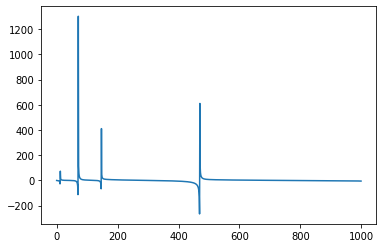

100%|██████████| 1000/1000 [00:06<00:00, 154.35it/s]

tensor(-5.82125, device='cuda:0', grad_fn=<SubBackward0>)
Epoch-999 lr: 0.005
exact solution =-3.0594539642333984


In [48]:
new = Net_auto()
new.to(device)

m = 0.1
nq = 8
# batch = torch.clone(basis).to(device)
# batch_size = 2**number_of_qubits
# batch_size = 150
# batch = make_batch(batch_size).to(device)
# print(batch.device)
t,y = permutations()
print(t,y)
batch_size = nq
batch = t.to(device)
dist = new.optimize(batch)
#plt.plot(dist[1:])

print('exact solution ={}'.format(c))

In [ ]:
torch.set_printoptions(precision=5)
eig_values = torch.eig(H, eigenvectors = True)[0][:, 0]
eig_vector = torch.eig(H, eigenvectors = True)[1]
c = eig_values.min()
m = torch.min(eig_values,0)[1]
R = eig_vector[:,m].reshape(2**number_of_qubits)
basis = basis.to(device)
#min_vector = eig_vector[:,m].reshape(1,2**number_of_qubits)
T = new(basis).detach().to(device)
T[basis == 0] = torch.sqrt(torch.abs(1 + 0.000001 - T[basis == 0]**2))
T = T.prod(dim = 1).reshape(2**number_of_qubits)
print(torch.dot(T,R))
#print(T.norm())
print(torch.matmul(torch.transpose(T.view(basis.shape[0],1), 0, 1), torch.matmul(H, T)))

tensor(0.99990, device='cuda:0')
tensor([-3.45871], device='cuda:0')


tensor(1.00000, device='cuda:0')


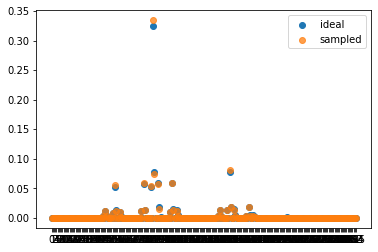

In [ ]:
import matplotlib.colors as mcolors
a = (R**2).to('cpu')
print(T.norm())
x = np.arange(0,2**number_of_qubits)
y = np.random.randint(1, 20, size = 2**number_of_qubits)
for i in range(0,2**number_of_qubits):
    y[i] = a[i]

z = torch.zeros(2**number_of_qubits)
#for i in range(0,2**number_of_qubits):
#    z[i] = times[i]
z = (T**2).to('cpu')

fig, ax = plt.subplots()
ax.scatter(x, a, alpha = 1, label='ideal')
ax.scatter(x, z, alpha = 0.75, label='sampled')
#ax.set_xticks(x)
ax.legend()
plt.show()

In [ ]:
def sample(batch): 
    times = torch.zeros(2**number_of_qubits)
    for i in range(2):
        for k in range(0,number_of_qubits):
            #print(k)
            batch_prob = new(batch)**2
            
            #print(batch_prob)
            u = torch.rand(batch_size)
            a = batch_prob[:,k]
            
            batch[u >= a, k] = 0
            batch[u < a, k] = 1
            #print(batch)
    #print(new(batch)**2)
        out, num = torch.unique(batch, return_counts = True,dim = 0) 
        a = 2**torch.arange(number_of_qubits -1, -1,-1)
        outt = out*a 
        outt = (outt.sum(dim=1)).type(torch.LongTensor)
        for i in range(len(outt)):
            times[outt[i]] += num[i]
    return times

In [ ]:
torch.set_printoptions(precision=6)
batch_size = 100

batch = make_batch(100)
times = sample(batch)
print(times)

tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  4.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  9.,  2.,  0.,
         0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  2.,  0., 21.,  1.,  0.,  0.,  0.,  0., 11.,
         0., 79., 15.,  0.,  0.,  9.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  2.,  0.,  9.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  5.,  2.,  0.,  0.,  0.,  0.,  2.,  0., 13.,  2.,  0.,  0.,  4.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  

In [ ]:
m = 0.1
print(m)

M = build_H.matrix(basis, m ,number_of_qubits)
print((M == H).prod())
print(number_of_qubits, m)

0.1
tensor(1)
5 0.1


In [ ]:
t = torch.ones(3)
print(t)
t = t.dot(t)
print(t)

tensor([1., 1., 1.])
tensor(3.)
